# 2008 database: $B_{pol}$ threshold scalings

C-Mod and pooled ITPA2008 (SELEC2007) data against $B_{pol}$, compared with the TC-26($B_{pol}$) scaling.

## Load

In [55]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

import _simdb_common as sc

db = sc.get_db()
sims = sc.query_dataset(db, "2008")
print(f"{len(sims)} shots in 2008")


2366 shots in 2008


In [56]:
rows = []
for i, sim in enumerate(sims, start=1):
    if i % 100 == 0 or i == len(sims):
        print(f"\r  {i}/{len(sims)} shots ({sim.alias})".ljust(80), end="", flush=True)

    md = sim.meta_dict()
    machine = md.get("machine", "")
    selec = sc.temp(md, "SELEC2007", n=0)
    n = len(selec)
    if n == 0:
        continue
    plth    = sc.path(md, "global_quantities", "power_loss", "value", n=n)
    pl      = sc.temp(md, "PL", n=n)
    splasma = sc.temp(md, "SPLASMA", "area_of_separatrix", n=n)
    bt      = np.abs(sc.path(md, "global_quantities", "b0", "value", n=n))
    nel     = sc.path(md, "line_average", "n_e", "value", n=n)
    meff    = sc.path(md, "volume_average", "meff_hydrogenic", "value", n=n)
    ip      = sc.path(md, "global_quantities", "ip", "value", n=n)
    rgeo    = sc.path(md, "boundary", "geometric_axis_r", "value", n=n)
    amin    = sc.path(md, "boundary", "minor_radius", "value", n=n)

    n_slices = min(len(a) for a in (selec, plth, pl, splasma, bt, nel, meff, ip, rgeo, amin))
    if n_slices == 0:
        continue
    sel = selec[:n_slices] == 1
    for j in range(n_slices):
        rows.append((machine, plth[j], pl[j], splasma[j], bt[j], nel[j], meff[j], ip[j],
                     rgeo[j], amin[j], bool(sel[j])))
print()

dtype = [("tok", "U16"), ("plth", float), ("pl", float), ("splasma", float), ("bt", float),
         ("nel", float), ("meff", float), ("ip", float), ("rgeo", float), ("amin", float),
         ("sel", bool)]
data = np.array(rows, dtype=dtype)

N       = len(data)
PLTH    = data["plth"]
PL      = data["pl"]
SPLASMA = data["splasma"]
BT      = data["bt"]
NEL     = data["nel"]
MEFF    = data["meff"]
IP      = data["ip"]
RGEO    = data["rgeo"]
AMIN    = data["amin"]
TOK     = data["tok"]
SEL     = data["sel"]

print("Done.")
print(f"N = {N} time-slices")
print(f"  SELEC2007=True : {np.sum(SEL)}")

  2366/2366 shots (2008/TUMAN-3M/26)                                           
Done.
N = 7692 time-slices
  SELEC2007=True : 1024


## Selection and derived variables

In [57]:
mask = SEL
m    = mask

Ploss_MW = np.where(np.isnan(PLTH), PL, PLTH) / 1e6  # [MW]
ne_20    = NEL / 1e20                                # [10^20 m^-3]
ip_ma    = np.abs(IP[m]) / 1e6                       # [MA]

P    = Ploss_MW[m]
Bt   = np.abs(BT[m])
ne   = ne_20[m]
Meff = MEFF[m]
S    = SPLASMA[m]
R    = RGEO[m]

Bpol = 2 * np.pi * sp.constants.mu_0 * (ip_ma * 1e6) * R / S
y    = np.log(P)

print(f"SELEC2007 = True : {np.sum(mask)}")
for tok in np.unique(TOK[mask]):
    print(f"  {tok}: {np.sum((TOK == tok) & mask)}")


SELEC2007 = True : 1024
  AUG: 175
  CMOD: 115
  D3D: 56
  JET: 562
  JFT2M: 58
  JT60U: 58


## $B_{pol}$ OLS pooled fit for entire ITPA2008 SELEC2007, $S$ exponent fixed to 1

In [58]:
tok_m = TOK[mask]

# S exponent fixed to 1: log P - log S = log C + ne_exp*log ne + Bpol_exp*log Bpol
A_1 = np.column_stack([np.ones_like(ne), np.log(ne), np.log(Bpol)])
z   = y - np.log(S)

coef_p, *_ = np.linalg.lstsq(A_1, z, rcond=None)
C_s1, ne_exp_s1, Bpol_exp_s1 = np.exp(coef_p[0]), coef_p[1], coef_p[2]

print(f"pooled : C = {C_s1:.4f}, ne_exp = {ne_exp_s1:.3f}, Bpol_exp = {Bpol_exp_s1:.3f}")


pooled : C = 0.1886, ne_exp = 0.941, Bpol_exp = 0.583


## Per-machine panels

Three density normalisations per machine: TC-26 (1.07), the pooled 2008 OLS fit, and the machine's own OLS fit. `IP_EDGES` holds the manual $I_p$ groupings.

In [ ]:
from IPython.display import display, Math

IP_EDGES = {   # [MA] manual Ip group boundaries, one list per machine
    "AUG":   [0.66, 0.755, 0.90, 1.11, 1.30],
    "CMOD":  [0.56, 0.71, 0.93, 1.085],
    "D3D":   [1.15, 1.60],
    "JET":   [1.25, 1.60, 2.35, 2.75, 3.50],
    "JFT2M": [0.17, 0.197, 0.225],
    "JT60U": [1.05, 1.70, 1.90, 2.20],
}

MARKERS = ["o", "s", "^", "D", "v", "P", "X"]
COLORS  = ["#1f77b4", "#d62728", "#2e7d32", "#9467bd", "#ff7f0e", "#8c564b", "#17becf"]


def fit_bpol(k):
    """Log-space OLS of P/S on (ne, Bpol) over mask k, S exponent fixed to 1."""
    A = np.column_stack([np.ones(np.sum(k)), np.log(ne[k]), np.log(Bpol[k])])
    coef, *_ = np.linalg.lstsq(A, y[k] - np.log(S[k]), rcond=None)
    return np.exp(coef[0]), coef[1], coef[2]


def fit_bt(k):
    """Same, but with Bt in place of Bpol."""
    A = np.column_stack([np.ones(np.sum(k)), np.log(ne[k]), np.log(Bt[k])])
    coef, *_ = np.linalg.lstsq(A, y[k] - np.log(S[k]), rcond=None)
    return np.exp(coef[0]), coef[1], coef[2]


def rmse(obs, pred):
    """Root mean of the squared errors normalized against observed values (rather
    than fitted)."""
    return float(np.sqrt(np.mean(((obs - pred) / obs) ** 2)))


def scaling_tex(name, C, ne_exp, x_sym, x_exp, tail=""):
    return (rf"\mathrm{{{name}}}:\  P_{{L-H}}/S = {C:.3f}\,\bar{{n}}_e^{{{ne_exp:.2f}}}"
            rf"{x_sym}^{{{x_exp:.2f}}}{tail}")


def panel_figure(tok):
    """TC-26, pooled-OLS and machine-only-OLS panels, each on its own ne normalisation."""
    k      = tok_m == tok
    S_t    = np.median(S[k])
    Meff_t = np.nanmedian(Meff[k])
    b_t    = np.linspace(Bpol[k].min(), Bpol[k].max(), 200)
    Ip_t   = ip_ma[k]
    Bt_t   = Bt[k]
    Bpol_t = Bpol[k]
    gid    = np.digitize(Ip_t, IP_EDGES[tok])

    C_t, ne_exp_t, Bpol_exp_t = fit_bpol(k)

    panels = [
        (1.07, 1.25 * 0.166 * S_t * b_t ** 0.631 * (2 / Meff_t) ** 1.01,
         rf"$1.25\times$ TC-26($B_{{pol}}$), $D$ = 1"),
        (ne_exp_s1, C_s1 * S_t * b_t ** Bpol_exp_s1,
         rf"2008 OLS: ${C_s1:.3f}\,S\,B_{{pol}}^{{{Bpol_exp_s1:.2f}}}$"),
        (ne_exp_t, C_t * S_t * b_t ** Bpol_exp_t,
         rf"{tok}-only OLS: ${C_t:.3f}\,S\,B_{{pol}}^{{{Bpol_exp_t:.2f}}}$"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharex=True, sharey=True)

    for i, (ax, (ne_exp, curve, curve_label)) in enumerate(zip(axes, panels)):
        y_p = P[k] / ne[k] ** ne_exp

        for g in np.unique(gid):
            kk = gid == g

            ax.plot(Bpol_t[kk],
                    y_p[kk],
                    MARKERS[g % len(MARKERS)],
                    ms=7.5,
                    mfc="none",
                    mec=COLORS[g % len(COLORS)],
                    mew=1.2,
                    label=rf"$I_p$ in [{Ip_t[kk].min():.2f}, {Ip_t[kk].max():.2f}] [MA] (n={np.sum(kk)})")

        (curve_line,) = ax.plot(b_t, curve, "--", lw=2, color="#37474f", zorder=5, label=curve_label)

        ax.set_xlabel(r"$B_{\mathrm{pol}}$  [T]")
        ax.set_ylabel(rf"$P_{{\mathrm{{loss}}}}\,/\,n_e^{{{ne_exp:.2f}}}$  [MW]")
        ax.grid(linestyle="dotted")
        if i == 0:
            ax.legend(fontsize=8, loc="upper left")      # Ip groups only once
        else:
            ax.legend(handles=[curve_line], fontsize=8, loc="upper left")

    fig.suptitle(f"{tok}, ITPA2008 database (SELEC2007)")
    fig.tight_layout()
    plt.savefig(f"figs/Bpol_{tok}_2008.png", dpi=900, bbox_inches="tight")
    plt.show()

    C_b, ne_exp_b, Bt_exp_b = fit_bt(k)

    P_k = P[k]
    rows = [
        (rf"1.25 \times \mathrm{{TC26}}:\  P_{{L-H}}/S = 1.25 \times 0.166"
         rf"\,\bar{{n}}_e^{{1.07}}B_{{pol}}^{{0.631}}",
         1.25 * 0.166 * S[k] * ne[k] ** 1.07 * Bpol[k] ** 0.631 * (2 / Meff_t) ** 1.01),
        (scaling_tex("pooled", C_s1, ne_exp_s1, "B_{pol}", Bpol_exp_s1),
         C_s1 * S[k] * ne[k] ** ne_exp_s1 * Bpol[k] ** Bpol_exp_s1),
        (scaling_tex(f"{tok} (Bpol)", C_t, ne_exp_t, "B_{pol}", Bpol_exp_t),
         C_t * S[k] * ne[k] ** ne_exp_t * Bpol[k] ** Bpol_exp_t),
        (scaling_tex(f"{tok} (Bt)", C_b, ne_exp_b, "B_t", Bt_exp_b),
         C_b * S[k] * ne[k] ** ne_exp_b * Bt[k] ** Bt_exp_b),
    ]

    for tex, pred in rows:
        display(Math(tex + rf"\quad \mathrm{{RMSE}} = {rmse(P_k, pred):.3f}"))

    d = rmse(P_k, rows[3][1]) - rmse(P_k, rows[2][1])
    display(Math(rf"\Delta\mathrm{{RMSE}}\ (B_t - B_{{pol}}) = {d:+.3f}"
                 rf"\quad \Rightarrow B_{{pol}}\, {r' \mathrm{better}' if d > 0 else r' \mathrm{worse}'}"))


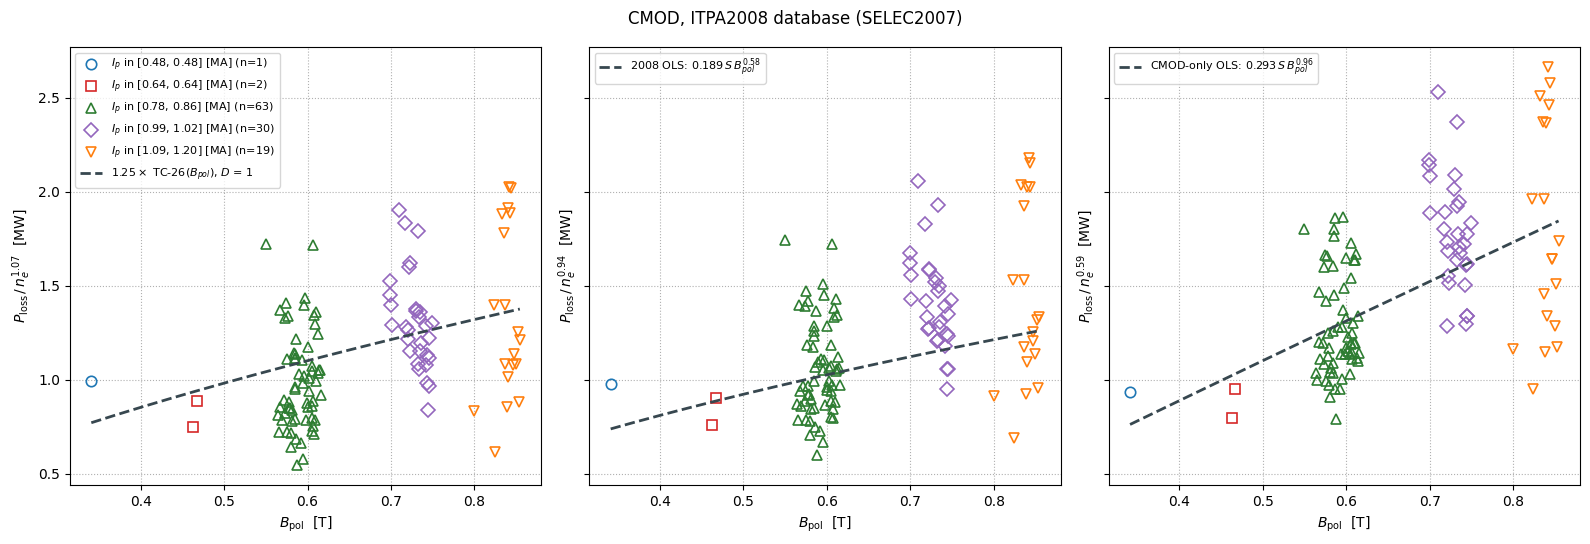

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [60]:
panel_figure("CMOD")


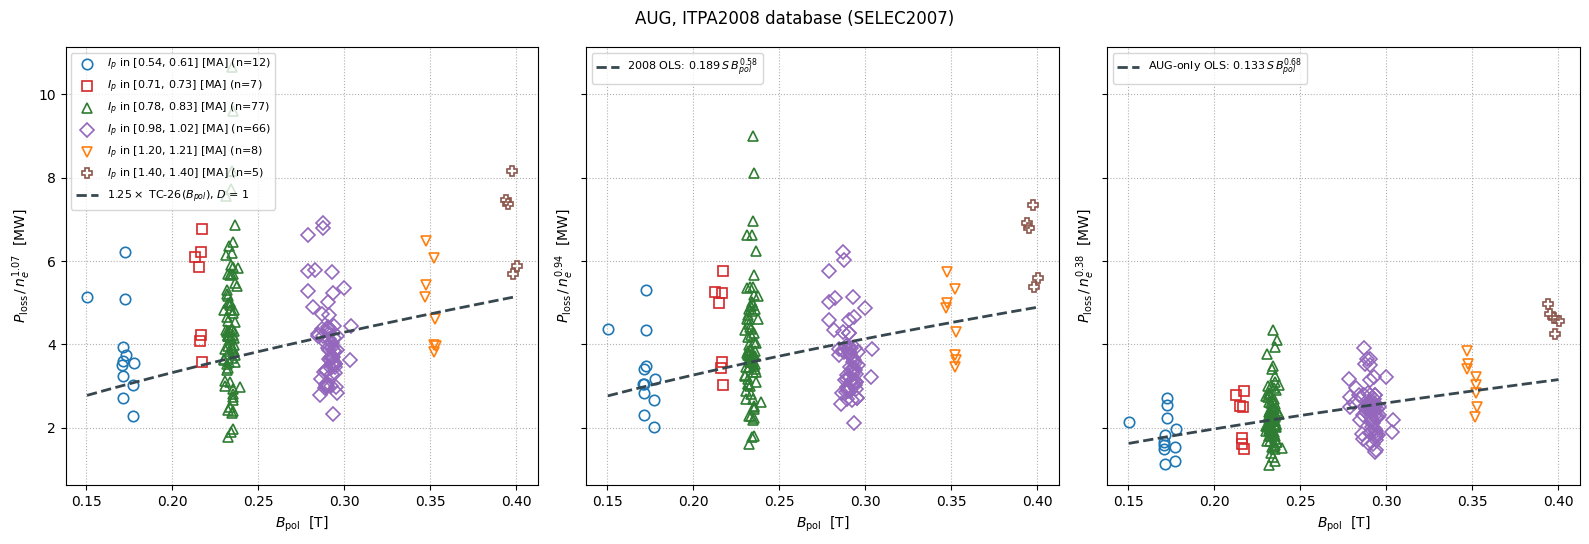

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [61]:
panel_figure("AUG")


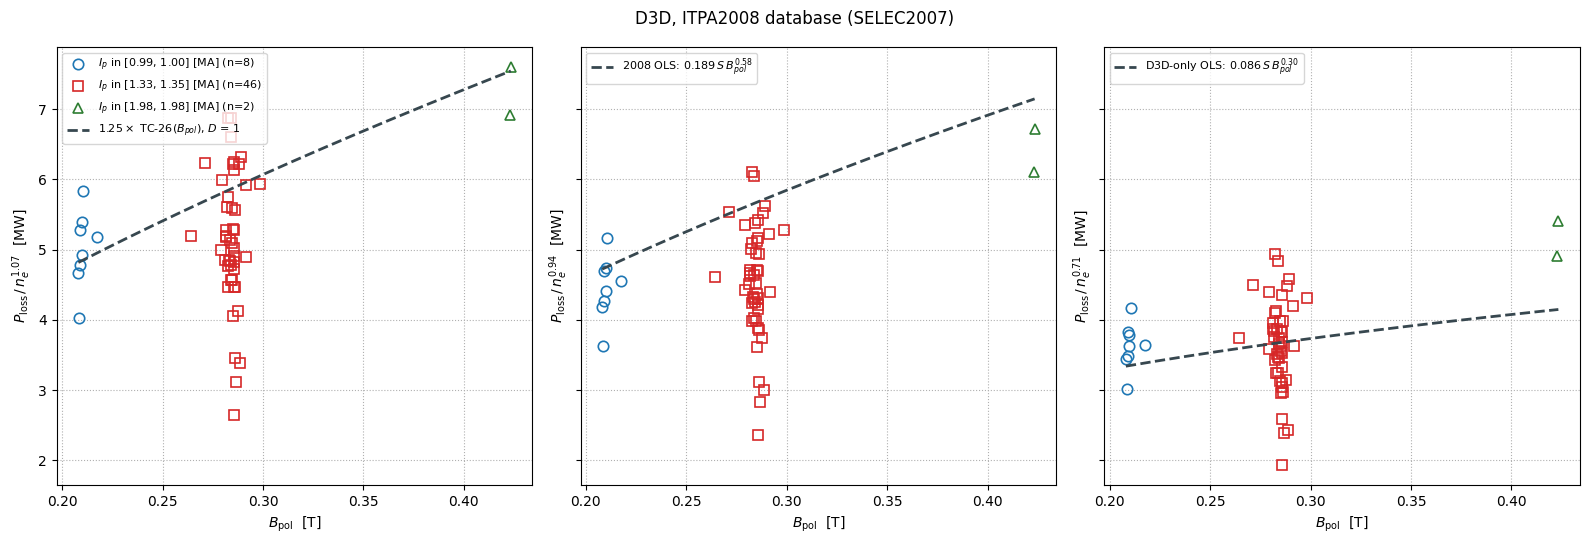

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [62]:
panel_figure("D3D")


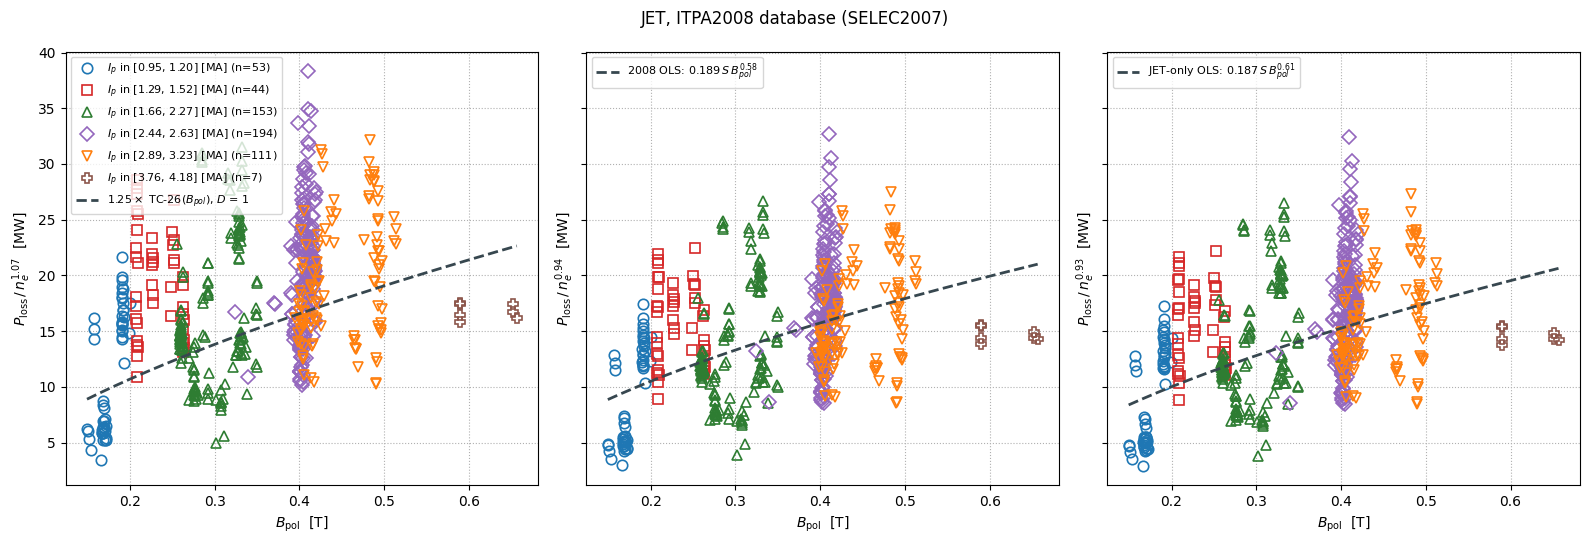

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [63]:
panel_figure("JET")


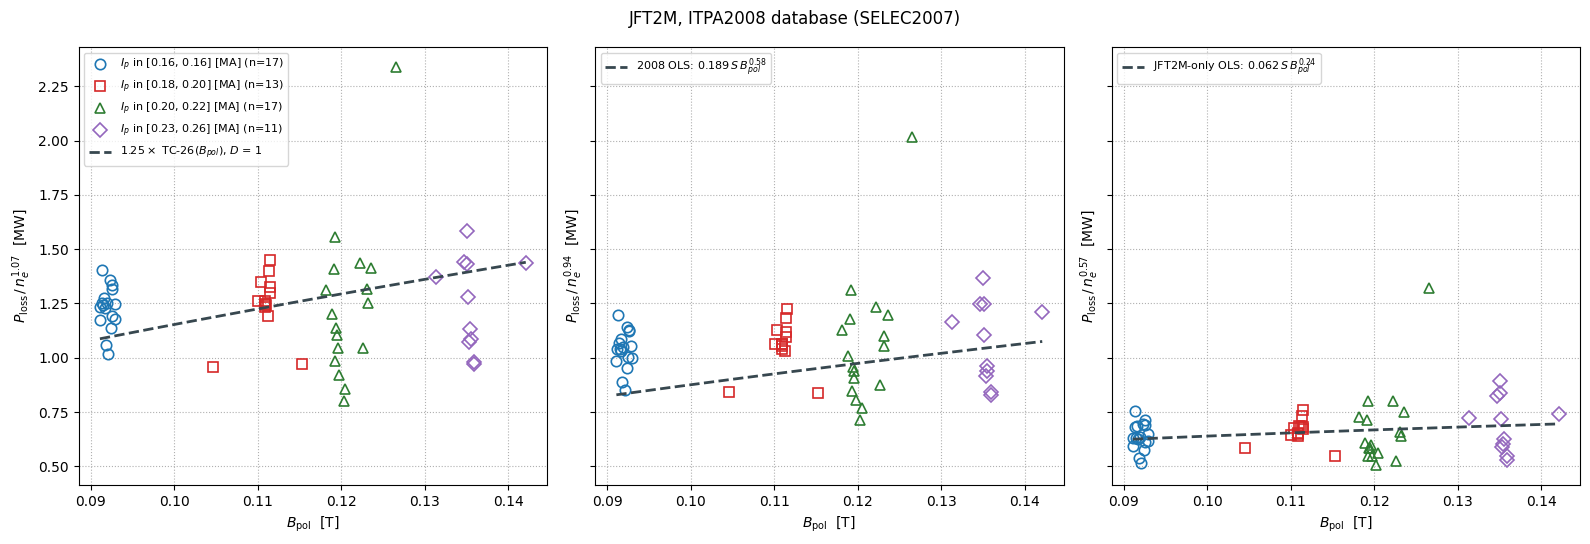

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [64]:
panel_figure("JFT2M")


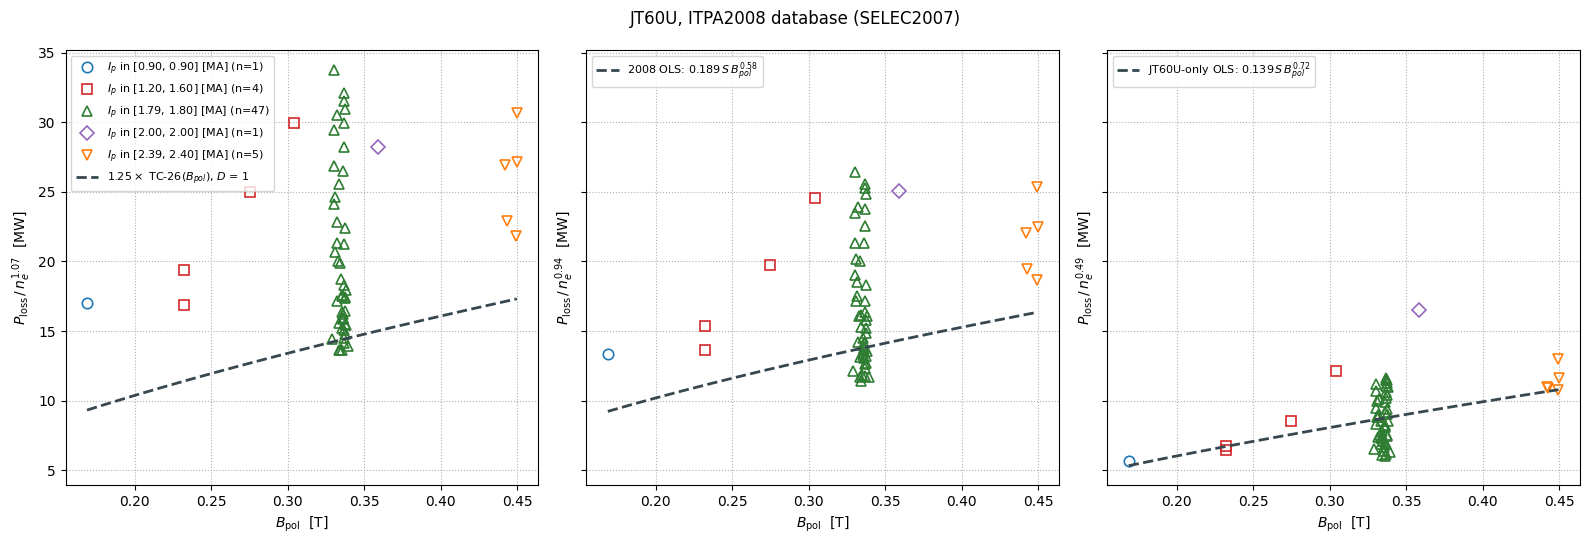

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [65]:
panel_figure("JT60U")


## All machines, $S$ divided out

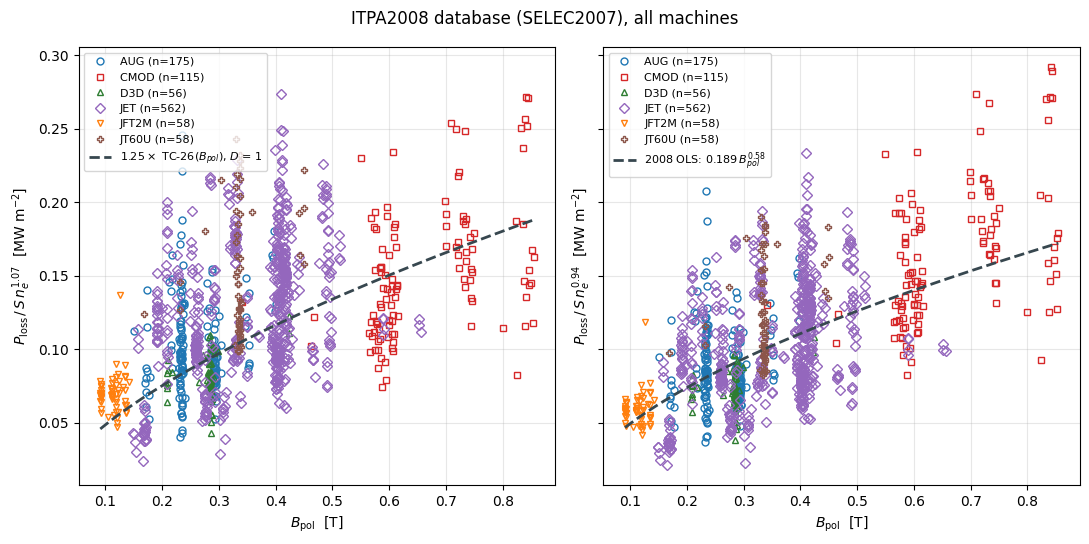

In [ ]:
b_all    = np.linspace(Bpol.min(), Bpol.max(), 200)
Meff_all = np.nanmedian(Meff)   # Meff carries NaNs for some slices

panels_all = [
    (1.07, 1.25 * 0.166 * b_all ** 0.631 * (2 / Meff_all) ** 1.01,
     rf"$1.25\times$ TC-26($B_{{pol}}$), $D$ = 1"),
    (ne_exp_s1, C_s1 * b_all ** Bpol_exp_s1,
     rf"2008 OLS: ${C_s1:.3f}\,B_{{pol}}^{{{Bpol_exp_s1:.2f}}}$"),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5), sharex=True, sharey=True)

for i, (ax, (ne_exp, curve, curve_label)) in enumerate(zip(axes, panels_all)):
    y_p = P / (S * ne ** ne_exp)

    for j, tok in enumerate(np.unique(tok_m)): # one marker/colour per machine
        k = tok_m == tok

        ax.plot(Bpol[k],
                y_p[k],
                MARKERS[j % len(MARKERS)],
                ms=5,
                mfc="none",
                mec=COLORS[j % len(COLORS)],
                mew=1.0,
                label=f"{tok} (n={np.sum(k)})")

    (curve_line,) = ax.plot(b_all, curve, "--", lw=2, color="#37474f", zorder=5, label=curve_label)

    ax.set_xlabel(r"$B_{\mathrm{pol}}$  [T]")
    ax.set_ylabel(rf"$P_{{\mathrm{{loss}}}}\,/\,S\,n_e^{{{ne_exp:.2f}}}$  [MW m$^{{-2}}$]")
    ax.grid(alpha=0.3, which="both")
    if i == 0:
        ax.legend(fontsize=8, loc = "upper left")          # machines only once
    else:
        ax.legend(fontsize=8, loc = "upper left")

fig.suptitle("ITPA2008 database (SELEC2007), all machines")
fig.tight_layout()
plt.savefig("figs/Bpol_allmachines_2008.png", dpi=900, bbox_inches="tight")
plt.show()
